In [3]:
import yfinance as yf
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px


In [4]:
ticker = "MANKIND.NS"

In [5]:


df = yf.download(
    ticker,
    start = "2020-01-01",
    end = "2026-01-01",
    auto_adjust=True
)

df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,MANKIND.NS,MANKIND.NS,MANKIND.NS,MANKIND.NS,MANKIND.NS
Date,,,,,
2023-05-09,1421.739624,1429.436541,1299.487765,1299.487765,33193796
2023-05-10,1382.305054,1423.788700,1339.471963,1416.441621,5651542
2023-05-11,1379.856079,1385.453848,1306.135140,1369.460153,5111576
2023-05-12,1393.900513,1438.233136,1356.515347,1363.462559,1946969
2023-05-15,1384.354370,1409.244584,1377.457064,1397.349248,565868


In [6]:
df.info()
df.describe()
df.isnull().sum()
df.tail()

<class 'pandas.DataFrame'>
DatetimeIndex: 656 entries, 2023-05-09 to 2025-12-31
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   (Close, MANKIND.NS)   656 non-null    float64
 1   (High, MANKIND.NS)    656 non-null    float64
 2   (Low, MANKIND.NS)     656 non-null    float64
 3   (Open, MANKIND.NS)    656 non-null    float64
 4   (Volume, MANKIND.NS)  656 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 30.8 KB


Price,Close,High,Low,Open,Volume
Ticker,MANKIND.NS,MANKIND.NS,MANKIND.NS,MANKIND.NS,MANKIND.NS
Date,,,,,
2025-12-24,2193.300049,2247.300049,2187.100098,2239.899902,269610
2025-12-26,2193.000000,2211.399902,2171.000000,2206.000000,254903
2025-12-29,2182.000000,2200.600098,2173.000000,2200.600098,294610
2025-12-30,2152.500000,2177.000000,2146.199951,2165.000000,301618
2025-12-31,2196.500000,2206.899902,2150.000000,2165.000000,215961


<function matplotlib.pyplot.show(close=None, block=None)>

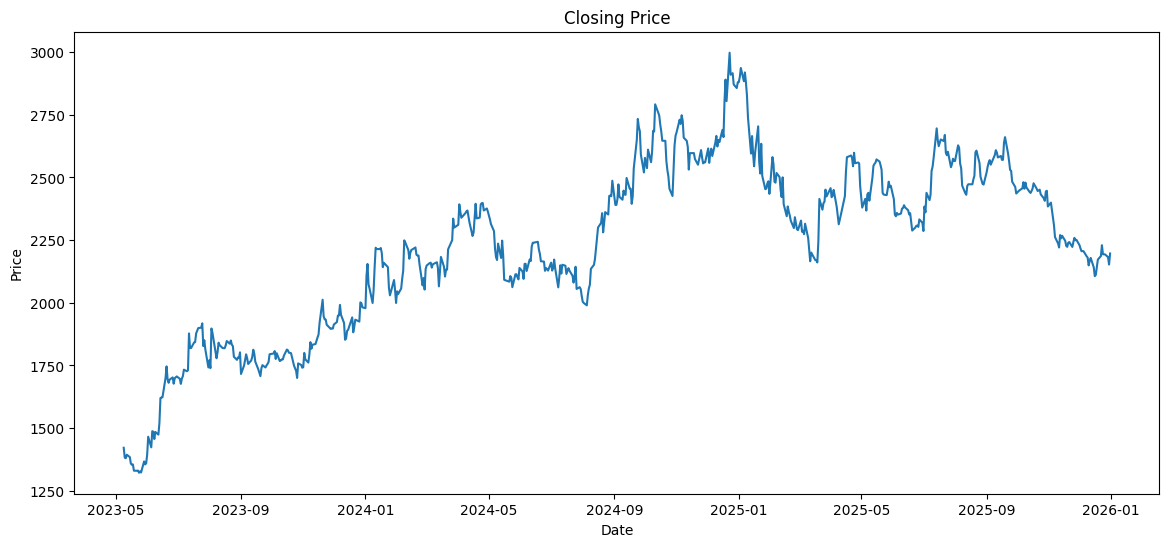

In [7]:
plt.figure(figsize=(14,6))

plt.plot(df.index, df["Close"])

plt.title("Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")

plt.show

In [8]:
fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=df["Close"][ticker],
        mode="lines",
        name="Closing Price"
    )
)

fig.update_layout(
    title = f"{ticker} Closing Prie",
    xaxis_title="Date",
    yaxis_title="Price"
)

fig.show()

In [9]:
df.to_csv(f"../data/{ticker}.csv")

## Basic Statistics

In [10]:
print("Number of the trading days : ", len(df))
print("Highest Closing Price : ", df["Close"][ticker].max())
print("Lowest Closing Price : ", df["Close"][ticker].min())
print("Average Closing Price : ", df["Close"][ticker].mean())
print("Median Closing Price : ", df["Close"][ticker].median())
print("Standard Closing Price : ", df["Close"][ticker].std())



Number of the trading days :  656
Highest Closing Price :  2997.218505859375
Lowest Closing Price :  1322.1287841796875
Average Closing Price :  2225.75304226759
Median Closing Price :  2254.0
Standard Closing Price :  340.3393197315083


### Highest & Lowest Price

In [11]:
print("Highest high : ", df["High"].max())
print("Lowest high : ", df["Low"].max())
print("Highest low Date : ", df["High"].idxmax())
print("Lowestest low Date : ", df["High"].idxmin())

Highest high :  Ticker
MANKIND.NS    3053.59643
dtype: float64
Lowest high :  Ticker
MANKIND.NS    2894.658851
dtype: float64
Highest low Date :  Ticker
MANKIND.NS   2024-12-23
dtype: datetime64[s]
Lowestest low Date :  Ticker
MANKIND.NS   2023-05-26
dtype: datetime64[s]


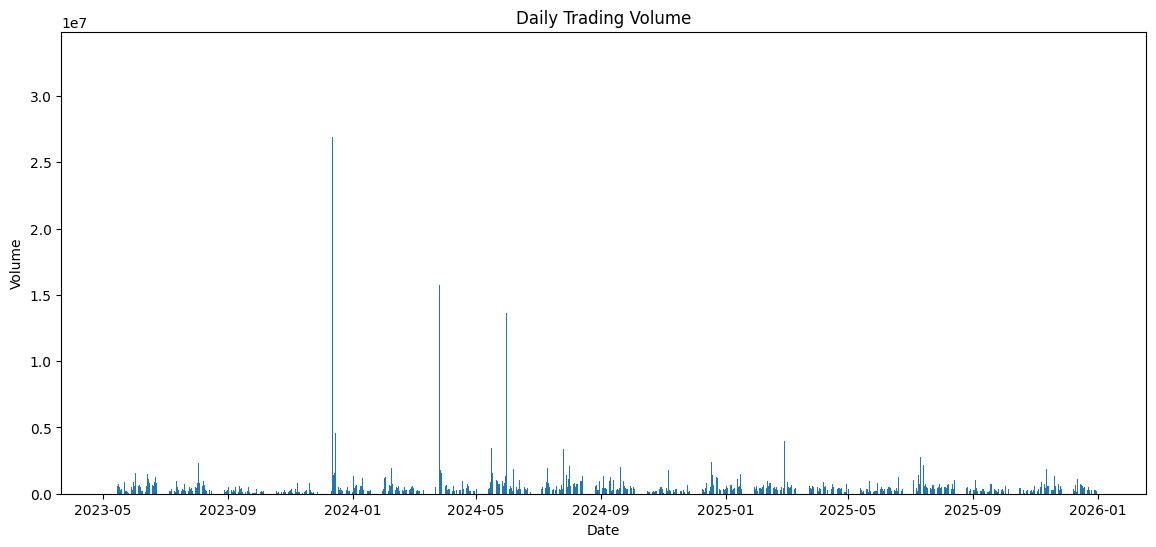

In [12]:
plt.figure(figsize=(14,6))
plt.bar(df.index, df["Volume"][ticker])
plt.title("Daily Trading Volume")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.show()

In [13]:
df.columns = df.columns.get_level_values(0)
fig = px.bar(
    df,
    x=df.index,
    y="Volume",
    title="Trading Volume"
)

fig.show()

### Daily Returns

In [14]:
df["Daily Returns"] = df["Close"].pct_change()*100
df.head()
df["Daily Returns"].describe()

count    655.000000
mean       0.085265
std        1.950325
min       -5.255574
25%       -1.130345
50%       -0.021978
75%        1.092678
max        9.101620
Name: Daily Returns, dtype: float64

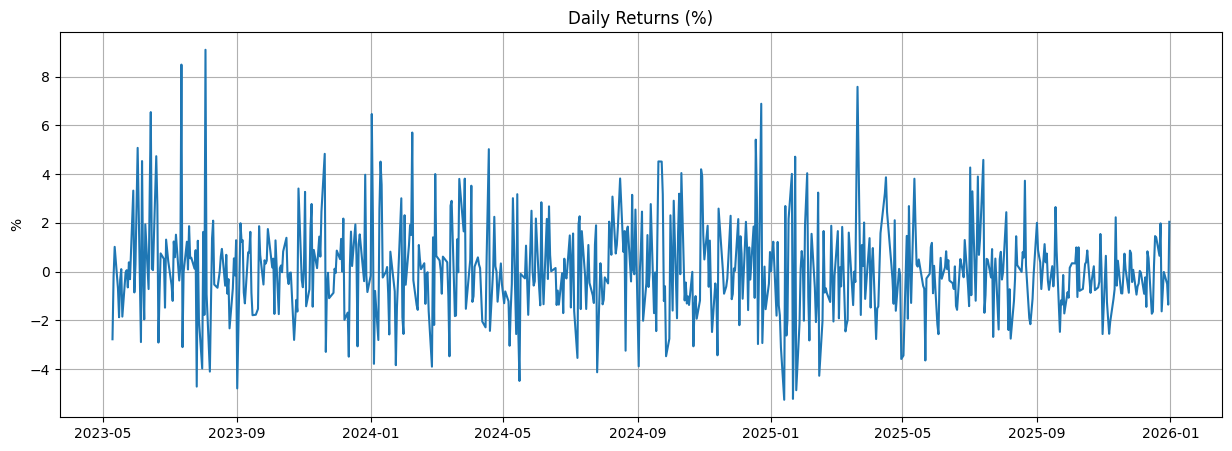

In [15]:
plt.figure(figsize=(15,5))
plt.plot(df.index, df["Daily Returns"])
plt.title("Daily Returns (%)")
plt.ylabel("%")
plt.grid(True)
plt.show()

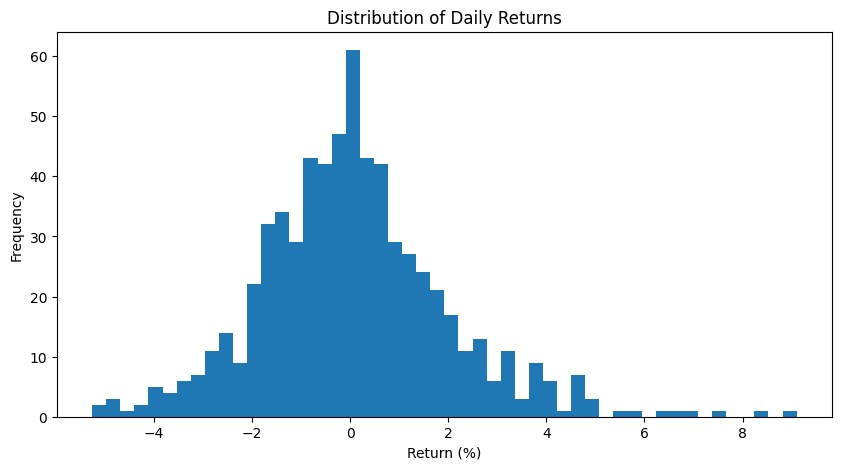

In [16]:
plt.figure(figsize=(10,5))
plt.hist(df["Daily Returns"].dropna(), bins=50)
plt.title("Distribution of Daily Returns")
plt.xlabel("Return (%)")
plt.ylabel("Frequency")
plt.show()

# Technical Indigator

### 20-Day SMA 

In [31]:
df["SMA20"] = df["Close"].rolling(window=20).mean()

### 50-Day SMA 

In [32]:
df["SMA50"] = df["Close"].rolling(window=50).mean()

### 200-Day SMA 

In [33]:
df["SMA200"] = df["Close"].rolling(window=200).mean()

In [34]:
df.tail()

Price,Close,High,Low,Open,Volume,Daily Returns,SMA20,SMA50,SMA200
Date,,,,,,,,,
2025-12-24,2193.300049,2247.300049,2187.100098,2239.899902,269610,-1.628097,2185.300012,2277.930015,2417.750565
2025-12-26,2193.000000,2211.399902,2171.000000,2206.000000,254903,-0.013680,2182.485010,2273.028013,2417.279324
2025-12-29,2182.000000,2200.600098,2173.000000,2200.600098,294610,-0.501596,2179.035010,2267.754014,2416.822305
2025-12-30,2152.500000,2177.000000,2146.199951,2165.000000,301618,-1.351971,2175.170007,2261.698013,2416.009117
2025-12-31,2196.500000,2206.899902,2150.000000,2165.000000,215961,2.044135,2174.175012,2256.096011,2415.699569


### Closing Price with SMAs

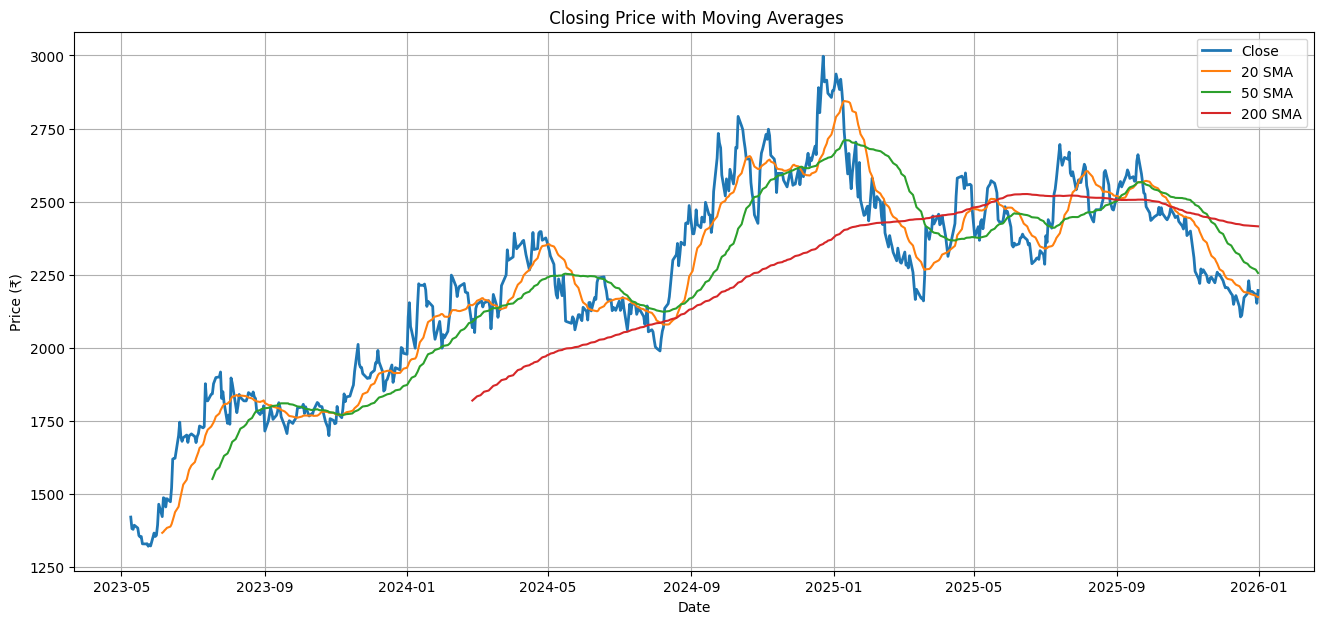

In [35]:
plt.figure(figsize=(16,7))

plt.plot(df.index, df["Close"], label="Close", linewidth=2)

plt.plot(df.index, df["SMA20"], label="20 SMA")

plt.plot(df.index, df["SMA50"], label="50 SMA")

plt.plot(df.index, df["SMA200"], label="200 SMA")

plt.title(" Closing Price with Moving Averages")

plt.xlabel("Date")

plt.ylabel("Price (₹)")

plt.legend()

plt.grid(True)

plt.show()

In [36]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df.index,
    y=df["Close"],
    mode="lines",
    name="Close"
))

fig.add_trace(go.Scatter(
    x=df.index,
    y=df["SMA20"],
    mode="lines",
    name="20 SMA"
))

fig.add_trace(go.Scatter(
    x=df.index,
    y=df["SMA50"],
    mode="lines",
    name="50 SMA"
))

fig.add_trace(go.Scatter(
    x=df.index,
    y=df["SMA200"],
    mode="lines",
    name="200 SMA"
))

fig.update_layout(
    title="Moving Averages",
    xaxis_title="Date",
    yaxis_title="Price (₹)",
    template="plotly_white"
)

fig.show()

# Exponential Moving Average (EMA)

### 20-Day EMA

In [37]:
df["EMA20"] = df["Close"].ewm(span=20, adjust=False).mean()

### 50-Day EMA

In [38]:
df["EMA50"] = df["Close"].ewm(span=50, adjust=False).mean()

### Plot EMA

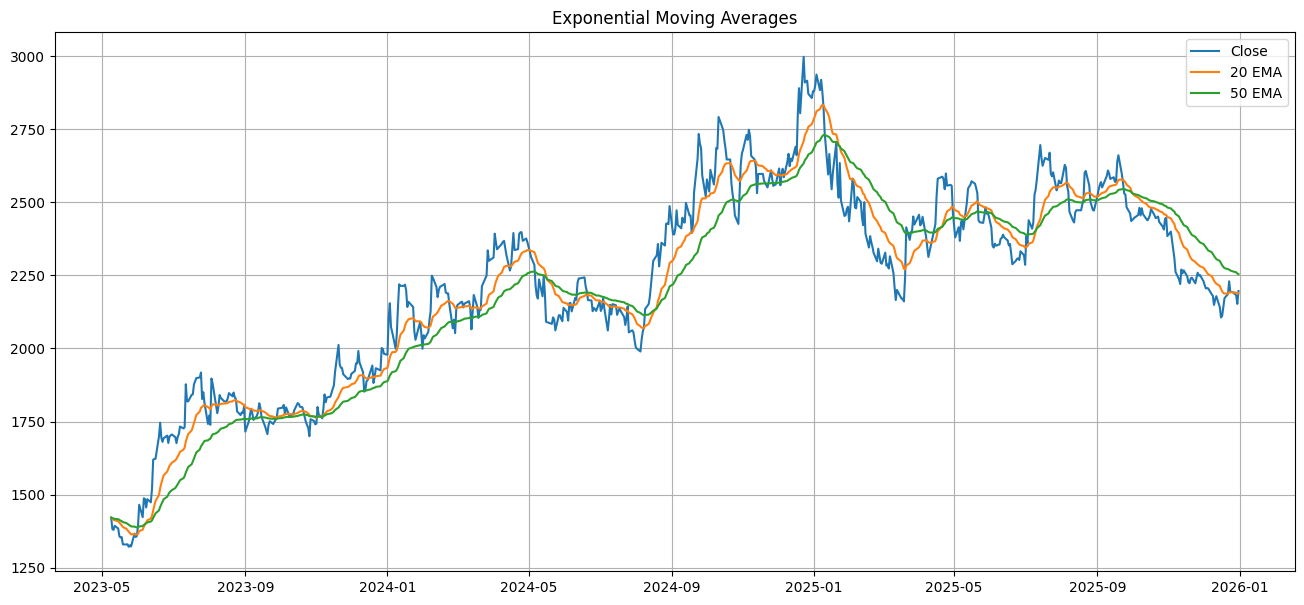

In [39]:
plt.figure(figsize=(16,7))

plt.plot(df.index, df["Close"], label="Close")

plt.plot(df.index, df["EMA20"], label="20 EMA")

plt.plot(df.index, df["EMA50"], label="50 EMA")

plt.legend()

plt.grid(True)

plt.title("Exponential Moving Averages")

plt.show()

### Compare SMA and EMA

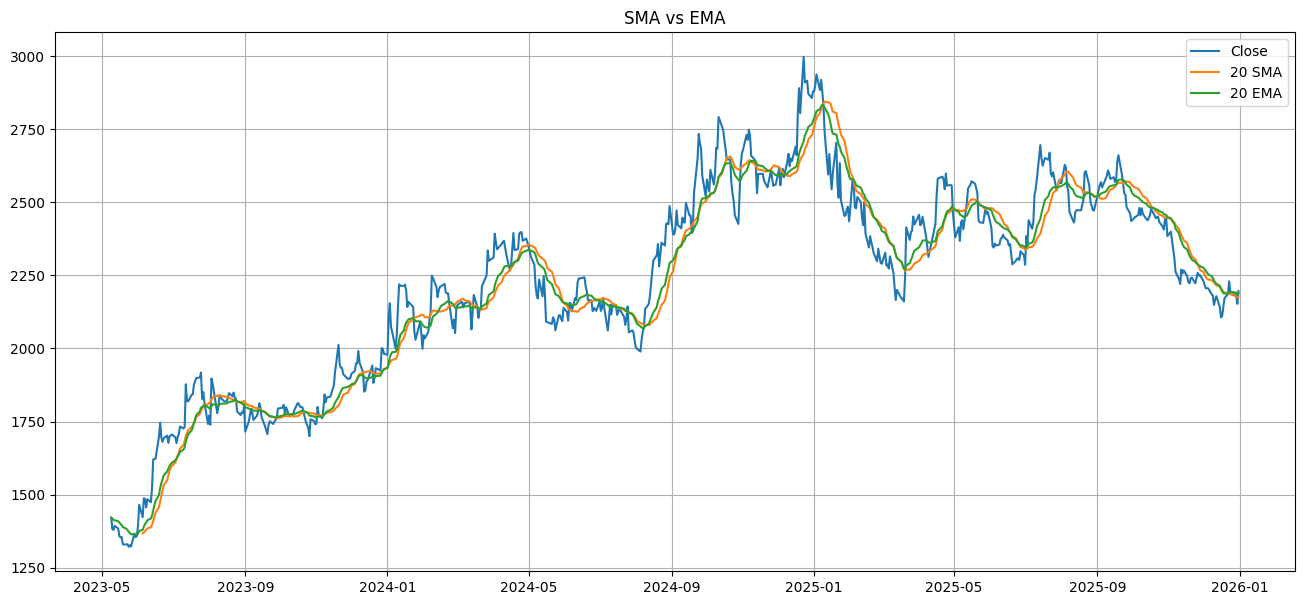

In [40]:
plt.figure(figsize=(16,7))

plt.plot(df.index, df["Close"], label="Close")

plt.plot(df.index, df["SMA20"], label="20 SMA")

plt.plot(df.index, df["EMA20"], label="20 EMA")

plt.legend()

plt.grid(True)

plt.title("SMA vs EMA")

plt.show()

# Bolinger Band

#### What are Bollinger Bands?

They consist of:

- Middle Band = 20-Day SMA
- Upper Band = SMA20 + 2 × Standard Deviation
- Lower Band = SMA20 - 2 × Standard Deviation

They help identify:

Overbought conditions
Oversold conditions
High or low volatility

## Standard Deviation

In [41]:
df["STD20"] = df["Close"].rolling(window=20).std()

### Upper Band

In [42]:
df["Upper Band"] = df["SMA20"] + (2 * df["STD20"])

### Lower Band

In [43]:
df["Lower Band"] = df["SMA20"] - (2 * df["STD20"])

In [44]:
df.tail()

Price,Close,High,Low,Open,Volume,Daily Returns,SMA20,SMA50,SMA200,EMA20,EMA50,STD20,Upper Band,Lower Band
Date,,,,,,,,,,,,,,
2025-12-24,2193.300049,2247.300049,2187.100098,2239.899902,269610,-1.628097,2185.300012,2277.930015,2417.750565,2191.949327,2266.595633,41.138633,2267.577277,2103.022747
2025-12-26,2193.000000,2211.399902,2171.000000,2206.000000,254903,-0.013680,2182.485010,2273.028013,2417.279324,2192.049391,2263.709530,38.361271,2259.207552,2105.762468
2025-12-29,2182.000000,2200.600098,2173.000000,2200.600098,294610,-0.501596,2179.035010,2267.754014,2416.822305,2191.092306,2260.505235,34.813818,2248.662645,2109.407374
2025-12-30,2152.500000,2177.000000,2146.199951,2165.000000,301618,-1.351971,2175.170007,2261.698013,2416.009117,2187.416848,2256.269735,33.131547,2241.433102,2108.906913
2025-12-31,2196.500000,2206.899902,2150.000000,2165.000000,215961,2.044135,2174.175012,2256.096011,2415.699569,2188.281910,2253.925824,32.111281,2238.397574,2109.952450


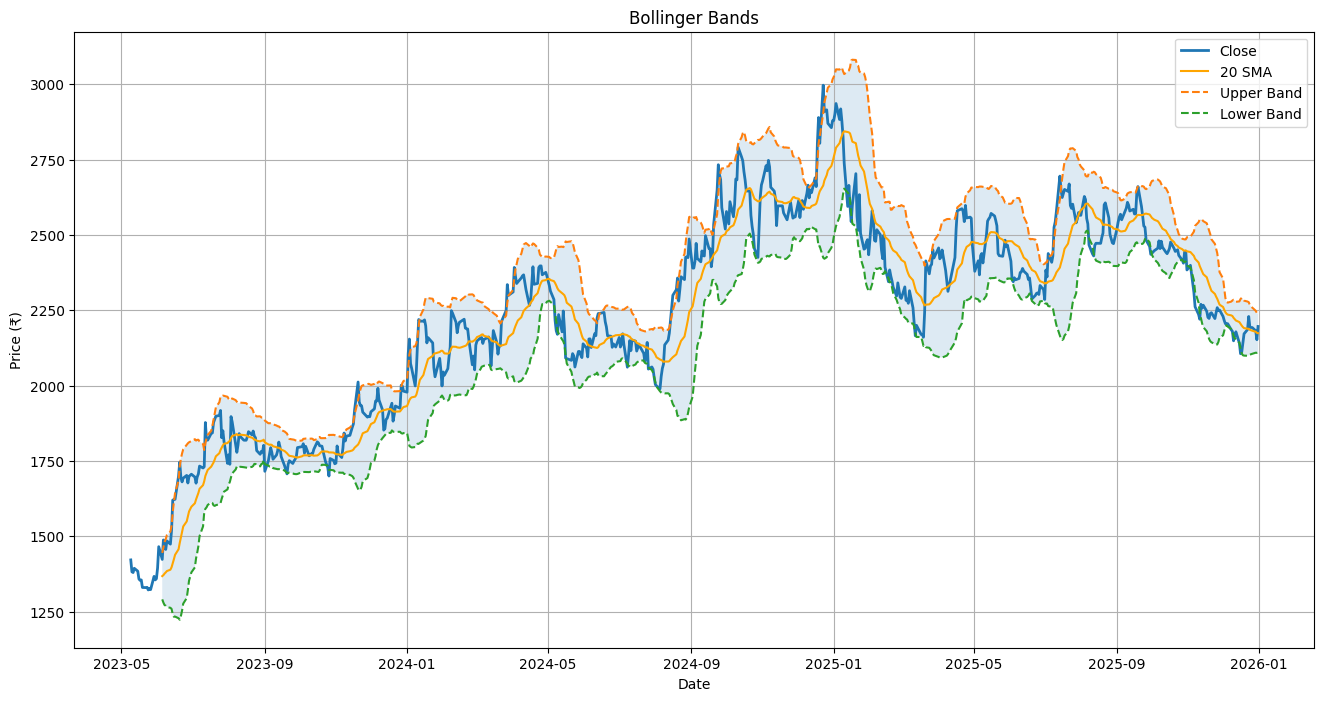

In [45]:
plt.figure(figsize=(16,8))

plt.plot(df.index, df["Close"], label="Close", linewidth=2)

plt.plot(df.index, df["SMA20"], label="20 SMA", color="orange")

plt.plot(df.index, df["Upper Band"], label="Upper Band", linestyle="--")

plt.plot(df.index, df["Lower Band"], label="Lower Band", linestyle="--")

plt.fill_between(
    df.index,
    df["Lower Band"],
    df["Upper Band"],
    alpha=0.15
)

plt.title("Bollinger Bands")

plt.xlabel("Date")

plt.ylabel("Price (₹)")

plt.legend()

plt.grid(True)

plt.show()

In [46]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df.index,
    y=df["Close"],
    name="Close"
))

fig.add_trace(go.Scatter(
    x=df.index,
    y=df["SMA20"],
    name="20 SMA"
))

fig.add_trace(go.Scatter(
    x=df.index,
    y=df["Upper Band"],
    name="Upper Band",
    line=dict(dash="dash")
))

fig.add_trace(go.Scatter(
    x=df.index,
    y=df["Lower Band"],
    name="Lower Band",
    line=dict(dash="dash")
))

fig.update_layout(
    title="Bollinger Bands",
    xaxis_title="Date",
    yaxis_title="Price (₹)",
    template="plotly_white"
)

fig.show()

### Band Width (Volatility)

In [48]:
df["Band Width"] = (
    (df["Upper Band"] - df["Lower Band"])
    / df["SMA20"]
) * 100

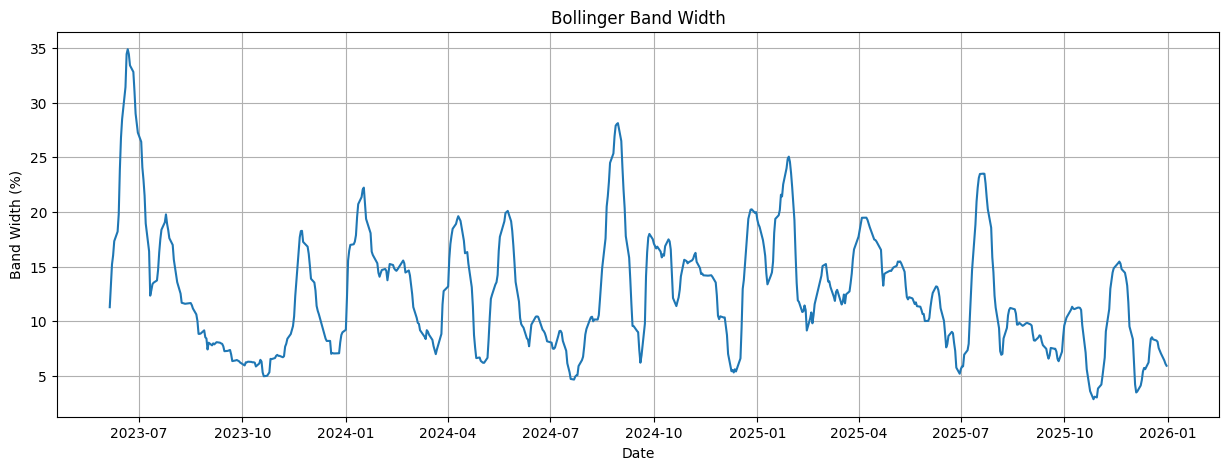

In [49]:
plt.figure(figsize=(15,5))

plt.plot(df.index, df["Band Width"])

plt.title("Bollinger Band Width")

plt.xlabel("Date")

plt.ylabel("Band Width (%)")

plt.grid(True)

plt.show()

## Detect Potential Signals

Find days where the closing price is above the upper band:

In [50]:
above_upper = df[df["Close"] > df["Upper Band"]]

print(above_upper[["Close", "Upper Band"]].tail())

Price             Close   Upper Band
Date                                
2025-07-04  2438.538818  2426.511423
2025-07-09  2525.604492  2479.420738
2025-07-10  2542.997559  2512.302155
2025-07-11  2577.284180  2550.071255
2025-07-14  2695.437500  2617.400215


### Find days where the closing price is below the lower band:

In [51]:
below_lower = df[df["Close"] < df["Lower Band"]]

print(below_lower[["Close", "Lower Band"]].tail())

Price             Close   Lower Band
Date                                
2025-11-11  2220.500000  2241.439595
2025-12-08  2185.500000  2187.591416
2025-12-10  2148.899902  2165.350996
2025-12-15  2141.199951  2142.356377
2025-12-16  2106.000000  2122.331737
